# Spam Email Classifier (NLP + Naive Bayes / SVM)

**Internship Project — Codec Technologies (AI Internship)**

This notebook builds a text classification model that detects whether a message (SMS/email) is **spam** or **ham (not spam)**.

**What this notebook covers:**
1. Loading a public spam dataset
2. Text cleaning and preprocessing (NLP)
3. Feature extraction with TF-IDF
4. Training Naive Bayes and SVM classifiers
5. Evaluating and comparing the models
6. Testing on custom messages
7. Saving the trained model

Just open this in Google Colab (`File > Upload Notebook`, or drag this `.ipynb` file in) and run all cells top to bottom (`Runtime > Run all`). It needs internet access (available by default in Colab) to download the small dataset.

## 1. Install & Import Libraries

In [1]:
import pandas as pd
import numpy as np
import re
import string
import matplotlib.pyplot as plt
import seaborn as sns

import nltk
nltk.download('stopwords')
from nltk.corpus import stopwords

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

import joblib

print("Libraries loaded successfully")

Libraries loaded successfully


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


## 2. Load the Dataset

We use the well-known **SMS Spam Collection** dataset (a public, widely used dataset for spam classification), fetched directly from a public GitHub mirror as a tab-separated file with two columns: label (`ham`/`spam`) and message text.

In [2]:
url = "https://raw.githubusercontent.com/justmarkham/pycon-2016-tutorial/master/data/sms.tsv"
df = pd.read_csv(url, sep='\t', header=None, names=['label', 'message'])

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (5572, 2)


,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


## 3. Explore the Data

label
ham     4825
spam     747
Name: count, dtype: int64


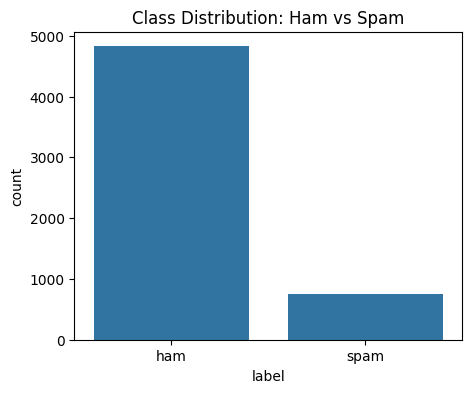

,message_length
label,
ham,71.482487
spam,138.670683


In [3]:
print(df['label'].value_counts())

plt.figure(figsize=(5, 4))
sns.countplot(x='label', data=df)
plt.title('Class Distribution: Ham vs Spam')
plt.show()

df['message_length'] = df['message'].apply(len)
df.groupby('label')['message_length'].mean()

## 4. Text Preprocessing

We clean each message by:
- Lowercasing
- Removing punctuation and numbers
- Removing stopwords (common words like 'the', 'is', 'and')

In [4]:
stop_words = set(stopwords.words('english'))

def clean_text(text):
    text = text.lower()
    text = re.sub(r'\d+', '', text)
    text = text.translate(str.maketrans('', '', string.punctuation))
    words = text.split()
    words = [w for w in words if w not in stop_words]
    return ' '.join(words)

df['clean_message'] = df['message'].apply(clean_text)
df[['message', 'clean_message']].head()

,message,clean_message
0,"Go until jurong point, crazy.. Available only ...",go jurong point crazy available bugis n great ...
1,Ok lar... Joking wif u oni...,ok lar joking wif u oni
2,Free entry in 2 a wkly comp to win FA Cup fina...,free entry wkly comp win fa cup final tkts st ...
3,U dun say so early hor... U c already then say...,u dun say early hor u c already say
4,"Nah I don't think he goes to usf, he lives aro...",nah dont think goes usf lives around though


## 5. Convert Labels & Split Data

In [5]:
df['label_num'] = df['label'].map({'ham': 0, 'spam': 1})

X = df['clean_message']
y = df['label_num']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train size:", len(X_train))
print("Test size:", len(X_test))

Train size: 4457
Test size: 1115


## 6. Feature Extraction with TF-IDF

In [6]:
vectorizer = TfidfVectorizer(max_features=3000)
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

print("TF-IDF matrix shape (train):", X_train_tfidf.shape)

TF-IDF matrix shape (train): (4457, 3000)


## 7. Train Model 1: Naive Bayes

In [7]:
nb_model = MultinomialNB()
nb_model.fit(X_train_tfidf, y_train)

nb_pred = nb_model.predict(X_test_tfidf)
nb_acc = accuracy_score(y_test, nb_pred)

print(f"Naive Bayes Accuracy: {nb_acc*100:.2f}%")
print(classification_report(y_test, nb_pred, target_names=['ham', 'spam']))

Naive Bayes Accuracy: 97.04%
              precision    recall  f1-score   support

         ham       0.97      1.00      0.98       966
        spam       0.99      0.79      0.88       149

    accuracy                           0.97      1115
   macro avg       0.98      0.89      0.93      1115
weighted avg       0.97      0.97      0.97      1115



## 8. Train Model 2: Support Vector Machine (SVM)

In [8]:
svm_model = SVC(kernel='linear', probability=True)
svm_model.fit(X_train_tfidf, y_train)

svm_pred = svm_model.predict(X_test_tfidf)
svm_acc = accuracy_score(y_test, svm_pred)

print(f"SVM Accuracy: {svm_acc*100:.2f}%")
print(classification_report(y_test, svm_pred, target_names=['ham', 'spam']))

SVM Accuracy: 98.39%
              precision    recall  f1-score   support

         ham       0.98      1.00      0.99       966
        spam       0.99      0.89      0.94       149

    accuracy                           0.98      1115
   macro avg       0.98      0.95      0.96      1115
weighted avg       0.98      0.98      0.98      1115



## 9. Compare Models with Confusion Matrices

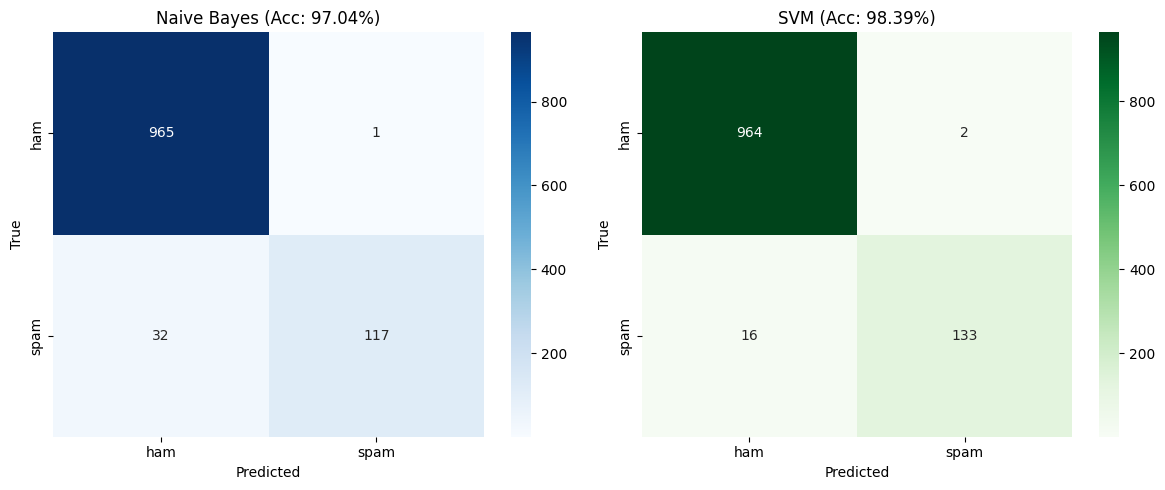

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

cm_nb = confusion_matrix(y_test, nb_pred)
sns.heatmap(cm_nb, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['ham', 'spam'], yticklabels=['ham', 'spam'])
axes[0].set_title(f'Naive Bayes (Acc: {nb_acc*100:.2f}%)')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('True')

cm_svm = confusion_matrix(y_test, svm_pred)
sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Greens', ax=axes[1],
            xticklabels=['ham', 'spam'], yticklabels=['ham', 'spam'])
axes[1].set_title(f'SVM (Acc: {svm_acc*100:.2f}%)')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('True')

plt.tight_layout()
plt.show()

## 10. Test on Custom Messages

In [10]:
def predict_message(text, model=svm_model):
    cleaned = clean_text(text)
    vec = vectorizer.transform([cleaned])
    pred = model.predict(vec)[0]
    return "SPAM" if pred == 1 else "HAM (Not Spam)"

test_messages = [
    "Congratulations! You've won a free iPhone. Click here to claim now!!!",
    "Hey, are we still meeting for lunch tomorrow?",
    "URGENT: Your account has been suspended. Verify your details immediately.",
    "Can you send me the report by end of day?"
]

for msg in test_messages:
    print(f"Message: {msg}")
    print(f"Prediction: {predict_message(msg)}")
    print("-" * 60)

Message: Congratulations! You've won a free iPhone. Click here to claim now!!!
Prediction: SPAM
------------------------------------------------------------
Message: Hey, are we still meeting for lunch tomorrow?
Prediction: HAM (Not Spam)
------------------------------------------------------------
Message: URGENT: Your account has been suspended. Verify your details immediately.
Prediction: SPAM
------------------------------------------------------------
Message: Can you send me the report by end of day?
Prediction: HAM (Not Spam)
------------------------------------------------------------


## 11. Save the Model and Vectorizer

In [11]:
joblib.dump(svm_model, 'spam_classifier_model.pkl')
joblib.dump(vectorizer, 'tfidf_vectorizer.pkl')
print("Model and vectorizer saved successfully")

Model and vectorizer saved successfully


## Conclusion

Both Naive Bayes and SVM perform well on this dataset (typically 95-98% accuracy), with SVM usually edging out slightly better precision on spam detection.

